In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error

In [2]:
# 1. Create synthetic regression dataset (nonlinear + noise)
np.random.seed(42)
X = np.sort(5 * np.random.rand(200, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.25, X.shape[0])

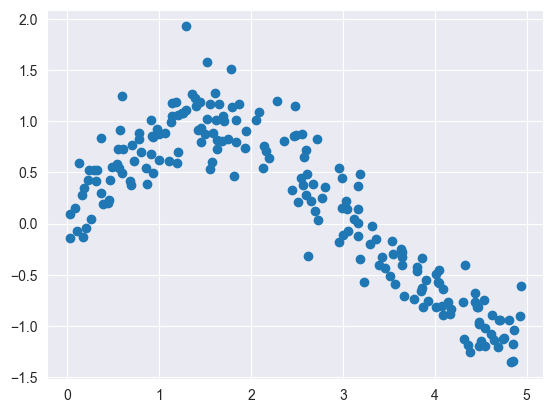

In [3]:
plt.scatter(X, y)

In [4]:
# Split into train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [5]:
# 2. Base learner: Decision Tree
base_tree = DecisionTreeRegressor(max_depth=5, random_state=42)

In [6]:
# Train single decision tree
base_tree.fit(X_train, y_train)
y_pred_tree = base_tree.predict(X_test)

In [7]:
# 3. Bagging with Decision Trees
bagging_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=5),
    n_estimators=50,              # number of trees
    max_samples=0.8,              # each tree trained on 80% bootstrap sample
    max_features=1.0,             # use all features
    bootstrap=True,               # bootstrap sampling ON
    random_state=42,
    n_jobs=-1                     # parallel jobs
)

bagging_reg.fit(X_train, y_train)
y_pred_bagging = bagging_reg.predict(X_test)

In [8]:
# 4. Evaluate
mse_tree = mean_squared_error(y_test, y_pred_tree)
mse_bagging = mean_squared_error(y_test, y_pred_bagging)

print(f"Decision Tree MSE: {mse_tree:.4f}")
print(f"Bagging Regressor MSE: {mse_bagging:.4f}")

Decision Tree MSE: 0.0922
Bagging Regressor MSE: 0.0873


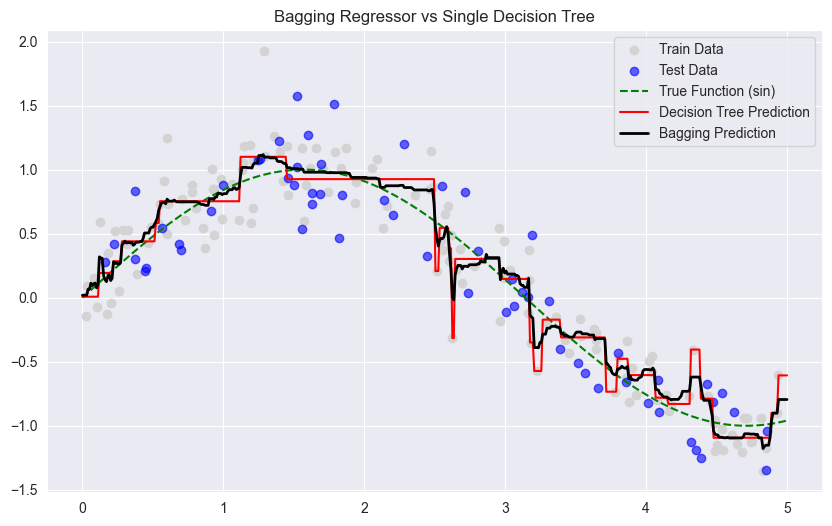

In [9]:
# 5. Visualization
X_plot = np.linspace(0, 5, 500).reshape(-1, 1)
y_tree_plot = base_tree.predict(X_plot)
y_bagging_plot = bagging_reg.predict(X_plot)

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, c="lightgray", label="Train Data")
plt.scatter(X_test, y_test, c="blue", alpha=0.6, label="Test Data")
plt.plot(X_plot, np.sin(X_plot), "g--", label="True Function (sin)")
plt.plot(X_plot, y_tree_plot, "r-", label="Decision Tree Prediction")
plt.plot(X_plot, y_bagging_plot, "k-", linewidth=2, label="Bagging Prediction")
plt.legend()
plt.title("Bagging Regressor vs Single Decision Tree")
plt.show()